# コブ＝ダグラス型関数

**コブ＝ダグラス型関数（Cobb–Douglas function）** は、投入要素間の代替の弾力性が1である生産関数や効用関数


:::{admonition} コブ＝ダグラス型生産関数

$$
Y=A  \prod_{i=1}^N X_i^{\alpha_i}
$$

- $Y$: 産出量
- $A$: 全要素生産性
- $X_i$: 投入量
- $\alpha_i$: 生産要素$i$の弾力性パラメータ

:::


## 2生産要素のコブ＝ダグラス型生産関数

:::{admonition} 2生産要素のコブ＝ダグラス型生産関数

$$
Y=A K^\alpha L^\beta
$$

- $Y$: 産出量
- $A$: 技術水準や全要素生産性
- $K$: 資本
- $L$: 労働
- $\alpha, \beta$: それぞれの要素の寄与の強さ

:::


### 性質

#### 1. 収穫逓減を表現できる

収穫逓減などは$\alpha, \beta$で設定できる

- $\alpha+\beta=1$: 収穫一定
- $\alpha+\beta>1$: 収穫逓増
- $\alpha+\beta<1$: 収穫逓減


#### 2. 限界生産力が計算しやすい

資本や労働を1単位増やしたときの増分が微分で簡単に出せる

労働の限界生産力は

$$
\frac{\partial Y}{\partial L}=A K^\alpha \beta L^{\beta-1}
$$


資本の限界生産力は

$$
\frac{\partial Y}{\partial K}=A \alpha K^{\alpha-1} L^\beta
$$

#### 3. 対数をとると線形になる

両辺の対数をとると

$$
\log Y=\log A+\alpha \log K+\beta \log L
$$

となるので、回帰分析で扱いやすい。

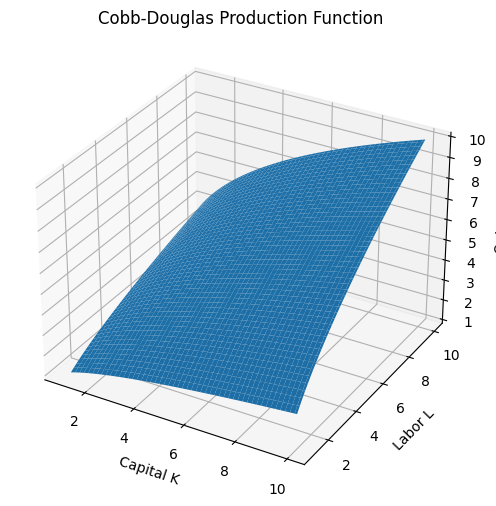

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# パラメータ
A = 1.0
alpha = 0.4
beta = 0.6

# 入力の範囲
K = np.linspace(1, 10, 100)   # 資本
L = np.linspace(1, 10, 100)   # 労働

# 格子点を作る
K_grid, L_grid = np.meshgrid(K, L)

# コブ＝ダグラス型生産関数
Y = A * (K_grid ** alpha) * (L_grid ** beta)

# 3Dプロット
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(K_grid, L_grid, Y)

ax.set_xlabel("Capital K")
ax.set_ylabel("Labor L")
ax.set_zlabel("Output Y")
ax.set_title("Cobb-Douglas Production Function")

plt.show()

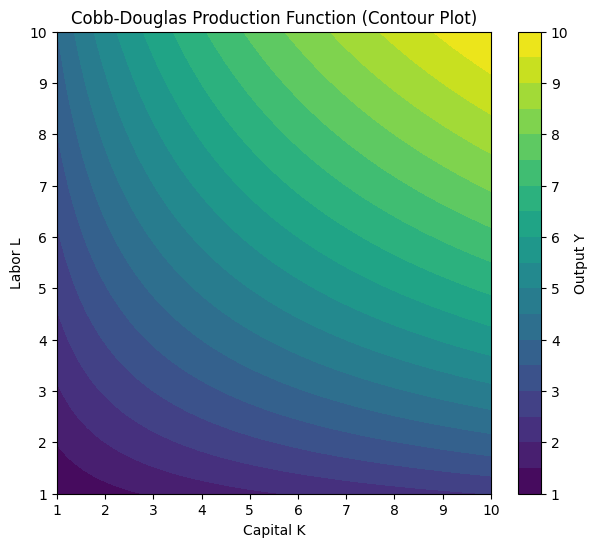

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# パラメータ
A = 1.0
alpha = 0.4
beta = 0.6

# 入力の範囲
K = np.linspace(1, 10, 200)
L = np.linspace(1, 10, 200)

K_grid, L_grid = np.meshgrid(K, L)
Y = A * (K_grid ** alpha) * (L_grid ** beta)

# 等高線プロット
plt.figure(figsize=(7, 6))
contour = plt.contourf(K_grid, L_grid, Y, levels=20)
plt.colorbar(contour, label="Output Y")

plt.xlabel("Capital K")
plt.ylabel("Labor L")
plt.title("Cobb-Douglas Production Function (Contour Plot)")
plt.show()

## 2財の効用関数

:::{admonition} 2財のコブ＝ダグラス型効用関数

$$
U(x, y)=x^\alpha y^\beta
$$

- $x, y$：各財の消費量
- $\alpha, \beta > 0$：効用に対する重み（選好の強さ）

:::

この関数は

- 両方の財をバランスよく消費すると効用が高い
- どちらか一方だけでは効用は伸びにくい（完全代替ではない）

という「滑らかで凸な選好」を表す。


### パラメータについての仮定

よく使われる仮定

- $\alpha > 0, \beta > 0$（単調性）
- $\alpha < 1, \beta < 1$（限界効用逓減）
- $\alpha + \beta = 1$（正規化）


### 性質

#### 1. 限界効用逓減

$$
MU_x = \frac{\partial U}{\partial x} = \alpha x^{\alpha-1} y^{\beta}
$$

$$
MU_y = \frac{\partial U}{\partial y} = \beta x^{\alpha} y^{\beta-1}
$$

消費が増えると限界効用は逓減（diminishing marginal utility）

具体的には

- 財 $x$ の限界効用が逓減する ⇔ $\alpha < 1$
- 財 $y$ の限界効用が逓減する ⇔ $\beta < 1$

#### 2. 限界代替率（MRS）

$$
MRS = \frac{MU_x}{MU_y} = \frac{\alpha}{\beta} \cdot \frac{y}{x}
$$

- 逓減する（無差別曲線が凸）
- 「xが多いほど、xの価値は相対的に下がる」

#### 3. 同次性（homothetic）

ある単調増加関数 $f$ と 同次関数 $V$ が存在して、効用関数 $U$を

$$
U(x)=f(V(x))
$$

と書ける選好を **相似拡大的選好（homothetic preferences）** という。

例えば2財の効用関数においては

$$
U(tx, ty) = t^{\alpha+\beta} U(x, y)
$$

を満たすとき、選好が相似拡大的であるという。コブ＝ダグラス型効用関数は相似拡大的である。

選好が相似拡大的であるとき、無差別曲線は「原点からの放射方向」にそのまま拡大される。つまり、消費の比率が同じなら所得が増えても好みは変わらないという性質になる


#### 4. 最適消費（需要関数）

予算制約

$$
p_x x + p_y y = I
$$

のもとで効用最大化する消費量は

$$
x^* = \frac{\alpha}{\alpha+\beta} \cdot \frac{I}{p_x}\\
y^* = \frac{\beta}{\alpha+\beta} \cdot \frac{I}{p_y}
$$

となる

解釈：

- 所得の一定割合を各財に使う（支出シェア一定）
- $\alpha, \beta$ が「支出比率」になる

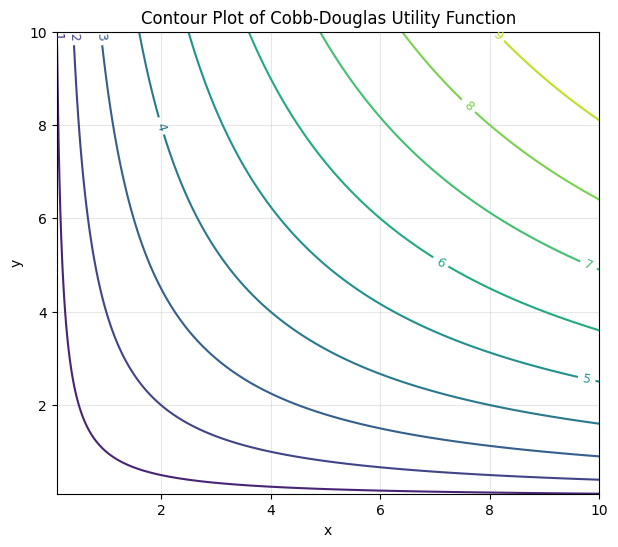

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# パラメータ
alpha = 0.5
beta = 0.5

# 財 x, y の範囲
x = np.linspace(0.1, 10, 300)
y = np.linspace(0.1, 10, 300)

# 格子点
X, Y = np.meshgrid(x, y)

# 効用関数
U = (X ** alpha) * (Y ** beta)

# 等高線プロット
plt.figure(figsize=(7, 6))
contour = plt.contour(X, Y, U, levels=10)
plt.clabel(contour, inline=True, fontsize=9)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Contour Plot of Cobb-Douglas Utility Function")
plt.grid(True, alpha=0.3)
plt.show()

## ビジネスでの応用例

$$
売上 = OOH広告^{\beta_{OOH}} \times TVCM^{\beta_{TVCM}} \times \epsilon
$$

[MMMモデルを推定した。で、結局どうやって予算最適化すればいいの？ #Python - Qiita](https://qiita.com/Gotoubun_taiwan/items/63103272d479d3471f6a)